In [ ]:
import sys, os
sys.path.append('d:\\pyrpl')
import pyrpl
print(sys.path) 

['c:\\Users\\eq15t\\anaconda3\\envs\\pyrpl-env\\python313.zip', 'c:\\Users\\eq15t\\anaconda3\\envs\\pyrpl-env\\DLLs', 'c:\\Users\\eq15t\\anaconda3\\envs\\pyrpl-env\\Lib', 'c:\\Users\\eq15t\\anaconda3\\envs\\pyrpl-env', '', 'c:\\Users\\eq15t\\anaconda3\\envs\\pyrpl-env\\Lib\\site-packages', 'c:\\Users\\eq15t\\anaconda3\\envs\\pyrpl-env\\Lib\\site-packages\\win32', 'c:\\Users\\eq15t\\anaconda3\\envs\\pyrpl-env\\Lib\\site-packages\\win32\\lib', 'c:\\Users\\eq15t\\anaconda3\\envs\\pyrpl-env\\Lib\\site-packages\\Pythonwin', 'd:\\pyrpl', 'C:\\Users\\eq15t\\anaconda3\\envs\\pyrpl-env\\Lib\\site-packages\\pyrpl', 'C:\\Users\\eq15t\\pyrpl_user_dir\\lockbox']


INFO:pyrpl.modules:reflection high-finesse calibration successful - Min: 0.027  Max: 0.261  Mean: 0.243  Rms: 0.043
INFO:pyrpl.modules:Not locked at stage 0: input transmission value of -0.01 +- 0.00 (setpoint 0.68)is not in error interval [0.47, inf].
INFO:pyrpl.modules:Locked at stage 2: input reflection value is 0.03 +- 0.00 (setpoint 0.03).
INFO:pyrpl.modules:Not locked at stage 2: input reflection value of 0.20 +- 0.00 (setpoint 0.03)is not in error interval [-inf, 0.14].
INFO:pyrpl.modules:Locked at stage 2: input reflection value is 0.03 +- 0.00 (setpoint 0.03).
INFO:pyrpl.modules:Not locked at stage 2: input reflection value of 0.51 +- 0.00 (setpoint 0.03)is not in error interval [-inf, 0.14].
INFO:pyrpl.modules:Locked at stage 2: input reflection value is 0.07 +- 0.00 (setpoint 0.03).
INFO:pyrpl.modules:reflection high-finesse calibration successful - Min: 0.060  Max: 0.536  Mean: 0.500  Rms: 0.087
INFO:pyrpl.modules:Not locked at stage 0: input transmission value of -0.01 +- 

In [2]:
from pyrpl.async_utils import wait, sleep_async, ensure_future

In [2]:
import numpy as np
import time
import copy
import matplotlib.pyplot as plt

In [2]:
p = pyrpl.Pyrpl('SHG_lock3')

INFO:pyrpl:All your PyRPL settings will be saved to the config file
    C:\Users\eq15t\pyrpl_user_dir\config\SHG_lock3.yml
If you would like to restart PyRPL with these settings, type "pyrpl.exe SHG_lock3" in a windows terminal or 
    from pyrpl import Pyrpl
    p = Pyrpl('SHG_lock3')
in a python terminal.
INFO:pyrpl.redpitaya:Correct FPGA image not detected, will reload
INFO:pyrpl.redpitaya:Found FPGA binfile at: c:\Users\eq15t\anaconda3\envs\pyrpl-env\Lib\site-packages\pyrpl\fpga/red_pitaya.bin
INFO:pyrpl.redpitaya:Found DTBO file at: c:\Users\eq15t\anaconda3\envs\pyrpl-env\Lib\site-packages\pyrpl\fpga/red_pitaya.dtbo
INFO:pyrpl.redpitaya:Loading FPGA via xdevcfg (old OS version)
INFO:pyrpl.redpitaya:Successfully connected to Redpitaya with hostname 192.168.1.100.


In [8]:
# Close UI
p._clear()

ERROR:paramiko.transport:Socket exception: Une connexion existante a dû être fermée par l’hôte distant (10054)


## Make some acquisition

In [ ]:
DATA_DIR = "data/pyrpl/"
os.makedirs(DATA_DIR, exist_ok=True)

In [ ]:
# Save curve in specified widget
curve = p.networkanalyzer.save_curve()

freq = np.array(curve.data[0])
tf = np.array(curve.data[1])   # complex transfer function

np.savez(
    os.path.join(DATA_DIR, "SHG_lock2_" + curve.name + ".npz"),
    freq=freq,
    tf=tf
)

### Oscilloscope

In [ ]:
# Oscilloscope

#start oscillo
p.rp.scope.continuous()

In [ ]:
print(p.rp.scope.running_state)

In [ ]:
#setup oscillo

p.rp.scope.input1 = 'iq1'
p.rp.scope.ch1_active = True

p.rp.scope.input2 = 'out1'
p.rp.scope.ch2_active = True

p.rp.scope.trigger_source = 'ch2_positive_edge'
p.rp.scope.duration = 2.5

In [ ]:
# Lock sequence in lock box module: sweep -> lock -> save oscillo trace
lb = p.lockbox

In [ ]:
print(lb.setup_attributes)
# current_config = copy.deepcopy(lb.setup_attributes)

In [ ]:
lb.sweep()
# wait(ensure_future(sleep_async(3.0)))

In [ ]:
lb.lock_async()
wait(ensure_future(sleep_async(2.0)))

# stop GUI/continuous acquisition
p.rp.scope.stop()  

x = np.array(p.rp.scope.data_x)
ch1 = np.array(p.rp.scope.data_avg[0])
ch2 = np.array(p.rp.scope.data_avg[1])

In [ ]:
print(x)
print(ch1)
print(ch2)

In [ ]:
# Save oscillo trace
file_name = "SHG_lock_oscillo_sequence" + time.strftime("%Y%m%d-%H%M%S") + ".npz"
np.savez(
    os.path.join(DATA_DIR, file_name),
    time=x,
    ch1=ch1,
    ch2=ch2
)


In [13]:
i1, i2, i3 , i4 = p.spectrumanalyzer.single()

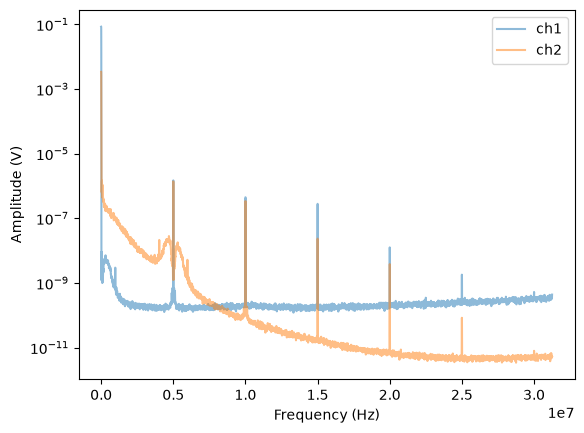

ERROR:paramiko.transport:Socket exception: Une connexion existante a dû être fermée par l’hôte distant (10054)
ERROR:paramiko.transport:Socket exception: Une connexion existante a dû être fermée par l’hôte distant (10054)


In [ ]:

plt.plot(p.spectrumanalyzer.frequencies , i1, label='ch1' , alpha=0.5, markersize=1)
plt.plot(p.spectrumanalyzer.frequencies , i2, label='ch2', alpha=0.5 , markersize=1)
# plt.plot(p.spectrumanalyzer.frequencies , i3, label='ch3')
# plt.plot(p.spectrumanalyzer.frequencies , i4, label='ch4')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude (V)')
plt.yscale('log')
plt.legend()
plt.show()